### Deep learning model training.
#### max accuracy:
#### u2net      
|model|miou(max)|oa(max)|update_time|pretrained|note|    
|----|----|----|----|----|----|
|U2Net+efficientnet_b0|94.5%|98.8%|20260525|True|| 
|U2Net+mobilenetv3_large_100|%|%|20260406|True||
|U2Net+resnet50|%|%|2026.4.7|True||
|U2Net+swinv2|%|%|2026.5.4|True||
||||||     

#### u3net      
|model|miou(max)|oa(max)|update_time|pretrained|note|    
|----|----|----|----|----|----|
|U3Net+efficientnet_b0|94.9%|98.9%|20260618|True|| 
||||||    


### conclusions:   
1. model training from pretrained parameters better than scrath.    
2. model with backbone better than unet.


In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
import time
import torch
import random
import pandas as pd
import torch.nn as nn
from glob import glob
from notebooks import config
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.imgShow import imsShow
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise
from utils.dataloader import read_scenes 
from model import u2net_timm, u2net_swin_timm
from utils.dataloader import SceneArraySet, PatchPathSet
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy


In [2]:
patch_size = 512  ## patch size setting
batch_size_tra = 4
batch_size_val = 16  ## speed up validation by setting a larger batch size.
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
paths_dem_tra = config.paths_dem_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 52
vali patch 512: 117


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, 
                                     paths_truth_tra, 
                                     paths_dem_tra) 


In [4]:
transforms_tra = v2.Compose([
            v2.ToImage(),
            v2.RandomCrop(size=(patch_size, patch_size)),
            v2.RandomHorizontalFlip(p=0.3),
            v2.RandomVerticalFlip(p=0.3),
            v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
            GaussianNoise(mean = 0.0, sigma_max_img=0.1, sigma_max_dem=0, p=0.3) 
            ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])  


In [5]:
# Create dataset instances
tra_data = SceneArraySet(scenes_arr=scenes_arr, 
                          truths_arr=truths_arr, 
                          patch_size=patch_size,
                          transforms=transforms_tra)
val_data = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)

## Create data loaders
tra_loader = torch.utils.data.DataLoader(tra_data, 
                                         batch_size=batch_size_tra, 
                                         shuffle=True, 
                                         num_workers=5)
val_loader = torch.utils.data.DataLoader(val_data, 
                                         batch_size=batch_size_val, 
                                         shuffle=False,
                                         num_workers=5)


#### Model training

In [6]:
model = u2net_timm(num_bands_b1=6, 
                    num_bands_b2=1, 
                    # backbone_name='resnet50',
                    # backbone_name='mobilenetv3_large_100',
                    backbone_name='efficientnet_b0',
                    pretrained=True,
                    )


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [7]:
# model = u2net_swin_timm(num_bands_b1=6, 
#                     num_bands_b2=1, 
#                     backbone_name="swinv2_base_window8_256", 
#                     img_size=512,  
#                     pretrained=True, 
#                     ) 


In [8]:
input_tensor = torch.randn(2, 7, 512, 512)  
output = model(input_tensor)  
output.shape  


torch.Size([2, 1, 512, 512])

In [9]:
### create loss and optimizer
# criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()
# criterion = GlacierLoss(aux_weight=1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
#                                           mode='min', 
#                                           factor=0.5,
#                                           min_lr=1e-5, 
#                                           patience=10)


In [10]:
'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,                     
                    epoches, 
                    device, 
                    lr_scheduler=None):
    loss_tra_loops, miou_tra_loops, oa_tra_loops = [], [], []
    loss_val_loops, miou_val_loops, oa_val_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    for epoch in range(epoches):
        start = time.time()
        loss_tra, loss_val = 0, 0
        '''-----train the model-----'''
        miou_tra = BinaryJaccardIndex().to(device)
        oa_tra = BinaryAccuracy().to(device)
        model.train()   # training mode for dropout and batchnorm
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            pred = (F.sigmoid(pred) > 0.5).float()
            miou_tra.update(pred, y_batch.long())
            oa_tra.update(pred, y_batch.long())
            loss_tra += loss.item()
        miou_tra_global = miou_tra.compute()
        oa_tra_global = oa_tra.compute()
        loss_tra_global = loss_tra/size_tra_loader
        miou_tra.reset(); oa_tra.reset()

        '''----- validation the model: time consuming -----'''
        oa_val = BinaryAccuracy().to(device)
        miou_val = BinaryJaccardIndex().to(device)
        model.eval()
        if epoch>500 and (epoch+1) % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                with torch.no_grad():
                    pred = model(x_batch)
                    # if x.shape[2] > 256:  ### crop inner 256x256 for evaluation
                    #     pred = v2.functional.center_crop(pred, 256)
                    #     y = v2.functional.center_crop(y, 256)
                    loss = loss_fn(pred, y_batch)
                pred = (F.sigmoid(pred) > 0.5).float()
                miou_val.update(pred, y_batch.long())
                oa_val.update(pred, y_batch.long())
                loss_val += loss.item()
            miou_val_global = miou_val.compute()
            oa_val_global = oa_val.compute()
            loss_val_global = loss_val/size_val_loader
            miou_val.reset(); oa_val.reset()

            loss_tra_loops.append(loss_tra_global); miou_tra_loops.append(miou_tra_global); oa_tra_loops.append(oa_tra_global)
            loss_val_loops.append(loss_val_global); miou_val_loops.append(miou_val_global); oa_val_loops.append(oa_val_global)
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, '
                    f'val-> Loss:{loss_val_global:.3f},Oa:{oa_val_global:.3f}, Miou:{miou_val_global:.3f},time:{time.time()-start:.1f}s')
        else: 
            print(f'Ep{epoch}: tra->Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(miou_tra_global)    ## if use lr_scheduler like ReduceLROnPlateau
        ## show the result
        if (epoch+1)%200 == 0:
            sam_index = random.randrange(len(val_data))
            patch, truth = val_data[sam_index]
            patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
            pred = model(patch)
            pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
            if patch.shape[2] > 256:  ## zoom in for visualization if patch size > 256
                pred_val = v2.functional.center_crop(pred, 256)
                patch_val = v2.functional.center_crop(patch, 256)
                truth_val = v2.functional.center_crop(truth, 256)
            else:
                patch_val = patch
                pred_val = pred
                truth_val = truth
            ## convert to numpy and plot
            patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred = pred[0].to('cpu').detach().numpy()
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch, pred, patch_val, pred_val, truth_val], 
                    clip_list = (2,0,2,0,0),
                    img_name_list=['input_patch', 'pred', 'patch_zoom_in', 'pred_zoom_in', 'truth_zoom_in'], 
                    figsize=(15, 3))
            plt.tight_layout() 
    metrics = {'tra_loss':loss_tra_loops, 'tra_oa': oa_tra_loops, 'tra_miou': miou_tra_loops,
                'val_loss': loss_val_loops, 'val_oa': oa_val_loops, 'val_miou': miou_val_loops}
    return metrics 


Ep0: tra->Loss:0.642,Oa:0.673,Miou:0.373,                                 time:3.4s
Ep1: tra->Loss:0.472,Oa:0.911,Miou:0.679,                                 time:2.9s
Ep2: tra->Loss:0.356,Oa:0.939,Miou:0.779,                                 time:3.0s
Ep3: tra->Loss:0.313,Oa:0.926,Miou:0.751,                                 time:3.0s
Ep4: tra->Loss:0.239,Oa:0.954,Miou:0.820,                                 time:2.9s
Ep5: tra->Loss:0.261,Oa:0.930,Miou:0.739,                                 time:2.9s
Ep6: tra->Loss:0.236,Oa:0.945,Miou:0.838,                                 time:2.8s
Ep7: tra->Loss:0.205,Oa:0.952,Miou:0.819,                                 time:2.9s
Ep8: tra->Loss:0.208,Oa:0.939,Miou:0.771,                                 time:3.0s
Ep9: tra->Loss:0.191,Oa:0.954,Miou:0.820,                                 time:3.1s
Ep10: tra->Loss:0.170,Oa:0.957,Miou:0.858,                                 time:2.9s
Ep11: tra->Loss:0.180,Oa:0.955,Miou:0.827,                                 

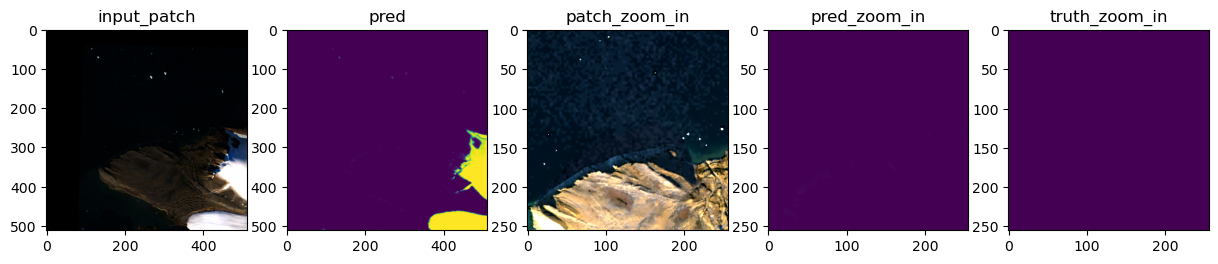

Ep200: tra->Loss:0.039,Oa:0.987,Miou:0.951,                                 time:3.1s
Ep201: tra->Loss:0.030,Oa:0.990,Miou:0.965,                                 time:3.1s
Ep202: tra->Loss:0.037,Oa:0.987,Miou:0.953,                                 time:3.1s
Ep203: tra->Loss:0.030,Oa:0.989,Miou:0.957,                                 time:3.2s
Ep204: tra->Loss:0.028,Oa:0.990,Miou:0.963,                                 time:2.9s
Ep205: tra->Loss:0.032,Oa:0.989,Miou:0.963,                                 time:2.8s
Ep206: tra->Loss:0.035,Oa:0.988,Miou:0.961,                                 time:2.9s
Ep207: tra->Loss:0.033,Oa:0.989,Miou:0.956,                                 time:3.2s
Ep208: tra->Loss:0.032,Oa:0.989,Miou:0.957,                                 time:3.0s
Ep209: tra->Loss:0.036,Oa:0.988,Miou:0.962,                                 time:2.8s
Ep210: tra->Loss:0.041,Oa:0.986,Miou:0.939,                                 time:2.8s
Ep211: tra->Loss:0.031,Oa:0.989,Miou:0.950,           

<Figure size 640x480 with 0 Axes>

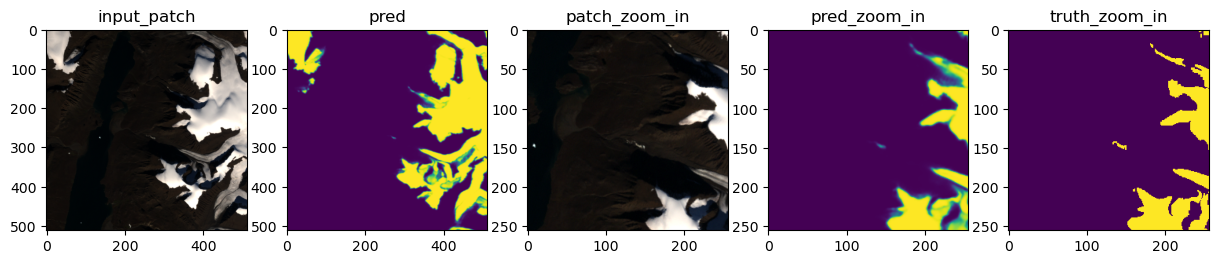

Ep400: tra->Loss:0.066,Oa:0.980,Miou:0.922,                                 time:2.9s
Ep401: tra->Loss:0.027,Oa:0.991,Miou:0.961,                                 time:2.9s
Ep402: tra->Loss:0.033,Oa:0.987,Miou:0.955,                                 time:2.8s
Ep403: tra->Loss:0.022,Oa:0.991,Miou:0.971,                                 time:3.0s
Ep404: tra->Loss:0.030,Oa:0.988,Miou:0.956,                                 time:3.2s
Ep405: tra->Loss:0.024,Oa:0.990,Miou:0.952,                                 time:3.0s
Ep406: tra->Loss:0.025,Oa:0.990,Miou:0.962,                                 time:3.0s
Ep407: tra->Loss:0.037,Oa:0.988,Miou:0.960,                                 time:3.0s
Ep408: tra->Loss:0.032,Oa:0.988,Miou:0.958,                                 time:3.1s
Ep409: tra->Loss:0.025,Oa:0.990,Miou:0.962,                                 time:3.2s
Ep410: tra->Loss:0.026,Oa:0.990,Miou:0.961,                                 time:3.1s
Ep411: tra->Loss:0.021,Oa:0.991,Miou:0.964,           

<Figure size 640x480 with 0 Axes>

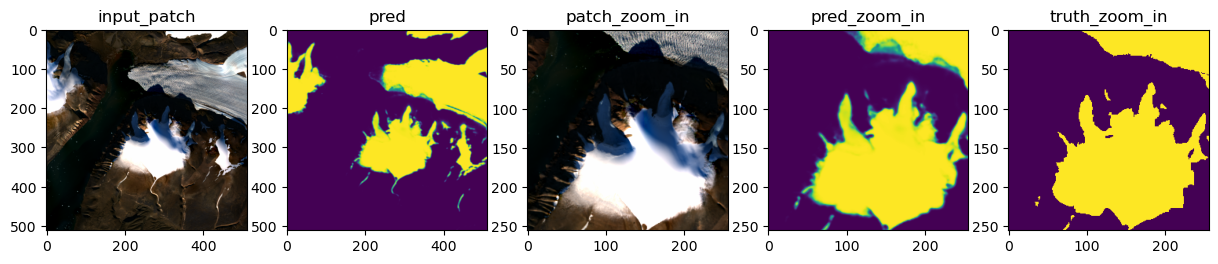

Ep600: tra->Loss:0.022,Oa:0.991,Miou:0.964,                                 time:3.3s
Ep601: tra->Loss:0.021,Oa:0.992,Miou:0.967,                                 time:3.2s
Ep602: tra-> Loss:0.028,Oa:0.989,Miou:0.958, val-> Loss:0.035,Oa:0.985, Miou:0.930,time:4.9s
Ep603: tra->Loss:0.028,Oa:0.989,Miou:0.963,                                 time:3.0s
Ep604: tra->Loss:0.017,Oa:0.993,Miou:0.972,                                 time:3.1s
Ep605: tra-> Loss:0.027,Oa:0.989,Miou:0.958, val-> Loss:0.035,Oa:0.985, Miou:0.930,time:4.7s
Ep606: tra->Loss:0.021,Oa:0.991,Miou:0.960,                                 time:3.0s
Ep607: tra->Loss:0.027,Oa:0.991,Miou:0.971,                                 time:3.0s
Ep608: tra-> Loss:0.023,Oa:0.991,Miou:0.961, val-> Loss:0.031,Oa:0.987, Miou:0.940,time:4.8s
Ep609: tra->Loss:0.023,Oa:0.990,Miou:0.963,                                 time:2.8s
Ep610: tra->Loss:0.023,Oa:0.991,Miou:0.960,                                 time:3.1s
Ep611: tra-> Loss:0.023,Oa:0.991,

<Figure size 640x480 with 0 Axes>

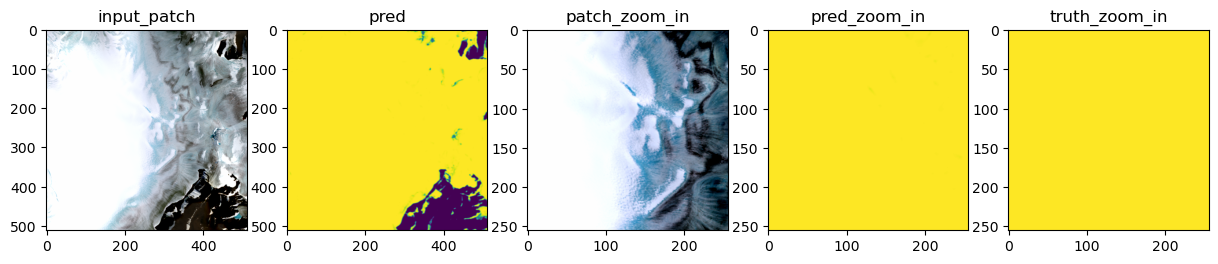

Ep800: tra-> Loss:0.021,Oa:0.991,Miou:0.965, val-> Loss:0.032,Oa:0.987, Miou:0.938,time:4.6s
Ep801: tra->Loss:0.023,Oa:0.991,Miou:0.956,                                 time:3.1s
Ep802: tra->Loss:0.023,Oa:0.991,Miou:0.972,                                 time:3.2s
Ep803: tra-> Loss:0.021,Oa:0.991,Miou:0.964, val-> Loss:0.035,Oa:0.985, Miou:0.928,time:4.8s
Ep804: tra->Loss:0.025,Oa:0.990,Miou:0.962,                                 time:3.2s
Ep805: tra->Loss:0.020,Oa:0.992,Miou:0.949,                                 time:3.0s
Ep806: tra-> Loss:0.019,Oa:0.993,Miou:0.967, val-> Loss:0.060,Oa:0.982, Miou:0.918,time:4.6s
Ep807: tra->Loss:0.019,Oa:0.992,Miou:0.972,                                 time:3.1s
Ep808: tra->Loss:0.023,Oa:0.991,Miou:0.959,                                 time:3.0s
Ep809: tra-> Loss:0.024,Oa:0.990,Miou:0.956, val-> Loss:0.029,Oa:0.988, Miou:0.943,time:4.8s
Ep810: tra->Loss:0.023,Oa:0.991,Miou:0.965,                                 time:3.1s
Ep811: tra->Loss:0.026,Oa:

<Figure size 640x480 with 0 Axes>

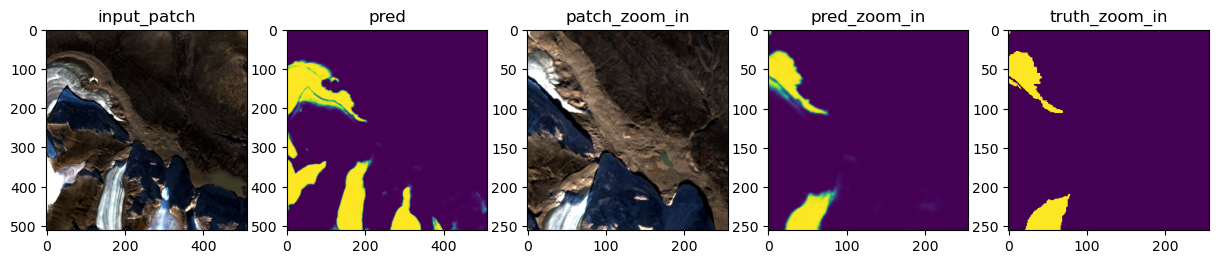

<Figure size 640x480 with 0 Axes>

In [11]:
device = torch.device('cuda:0') 
metrics = train_loops(model=model, 
                epoches=1000,  
                loss_fn=criterion,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  
torch.save(model.state_dict(), 'model/trained/u2net_timm.pth')


In [12]:
# # model saving 
# # model_name = 'unet' 
# # model_name = 'unet_att' 
# model_name = 'u2net_cbam' 
# # model_name = 'deeplabv3plus'  
# # model_name = 'deeplabv3plus_mb2' 
# date_str = time.strftime("%Y-%m-%d-%H", time.localtime())
# date_str = date_str.replace('-', '')  ## remove '-' for file name
# # path_save = f'model/trained/{model_name}/{model_name}_weights_1.pth'
# path_save = f'model/trained/seg_models/{model_name}_weights_{date_str}.pth'
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# ## model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# ## metrics saving
# path_metrics = f'model/trained/seg_models/{model_name}_metrics_{date_str}.csv'    
# ## path_metrics = f'model/trained/{model_name}/{model_name}_metrics_1.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
